In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [26]:
# Read in data
data = pd.read_csv("~/Documents/2023:2024/Data/Exported data/maintainer_superager_data.csv")

In [27]:
# Look at age data for all available cross-sectional data (merged cohort data)

participants = data["w1_age"].count()
mean_age = data["w1_age"].mean()
sd_age = data["w1_age"].std()
mean_fu = data["mem_time"].mean()
sd_fu = data["mem_time"].std()
sex_count_f = data["sex"].value_counts()["female"]


print(f"Number of participants: {participants}")
print(f"Mean age: {mean_age:.2f} (SD: {sd_age:.2f})")
print(f"Mean follow-up time: {mean_fu:.2f} (SD: {sd_fu:.2f})")
print(f"Number of females: {sex_count_f}")

Number of participants: 220
Mean age: 67.26 (SD: 5.65)
Mean follow-up time: 2.17 (SD: 0.37)
Number of females: 127


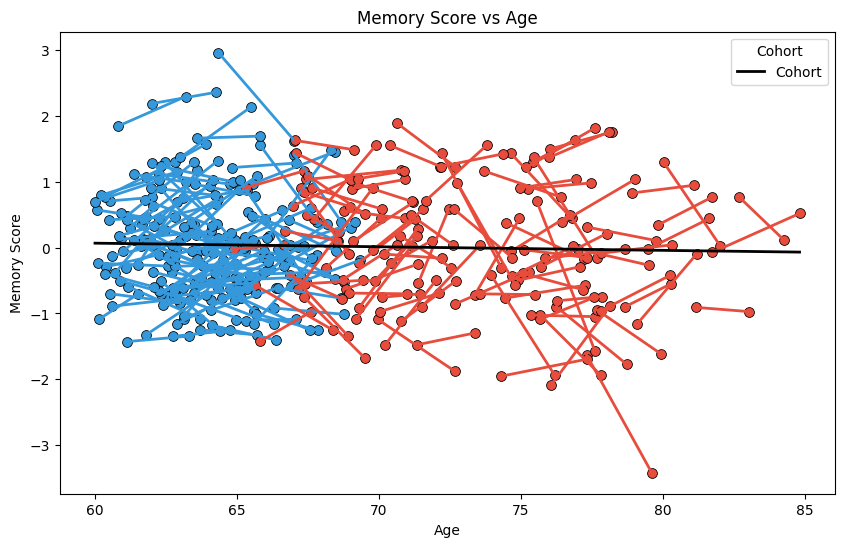

In [28]:
# Create a new DataFrame where each row corresponds to a unique id and timepoint
data_long = pd.DataFrame({
    "id": np.repeat(data["id"].values, 2),
    "age": data[["w1_age", "w2_age"]].values.flatten(),
    "memory": data[["w1_memory", "w2_memory"]].values.flatten(),
    "superager": np.repeat(data["superager"].values, 2),
    "maintainer": np.repeat(data["maintainer"].values, 2),
})

# Fit the mixed-effects model for the entire cohort
model_cohort = MixedLM.from_formula("memory ~ age", groups="id", data=data_long)
result_cohort = model_cohort.fit()

# Define cohort based on 'id'
data_long["cohort"] = np.where(data_long["id"] > 10000, "bbhi", "bbhi_senior")

# Create the plot for memory
plt.figure(figsize=(10, 6))

# Assign colors based on cohort
palette = {"bbhi": "#3498db", "bbhi_senior": "#e74c3c"}

# Plot a line for each person with different colors based on cohort
for cohort, color in palette.items():
    subset = data_long[data_long["cohort"] == cohort]
    for id in subset["id"].unique():
        person_data = subset[subset["id"] == id]
        sns.lineplot(data=person_data, x="age", y="memory", color=color, linewidth=2)
        sns.scatterplot(data=person_data, x="age", y="memory", color=color, s=50, edgecolor="black")

# Plot the fitted line for the entire cohort
group_line = result_cohort.predict(data_long)
sns.lineplot(x=data_long["age"], y=group_line, color="black", linewidth=2, label="Cohort")

plt.xlabel("Age")
plt.ylabel("Memory Score")
plt.title("Memory Score vs Age")
plt.legend(title="Cohort")
plt.show()

In [29]:
# Define conditions
conditions = [
    (data["maintainer"] == 1) & (data["superager"] == 1),
    (data["maintainer"] == 0) & (data["superager"] == 1),
    (data["maintainer"] == 1) & (data["superager"] == 0),
    (data["maintainer"] == 0) & (data["superager"] == 0),
]

# Define corresponding values
values = ["superager maintainer", "superager decliner", "non-superager maintainer", "non-superager decliner"]

# Use np.select with a default string to ensure consistent dtype
data["superager_maintainer"] = np.select(conditions, values, default="unknown")

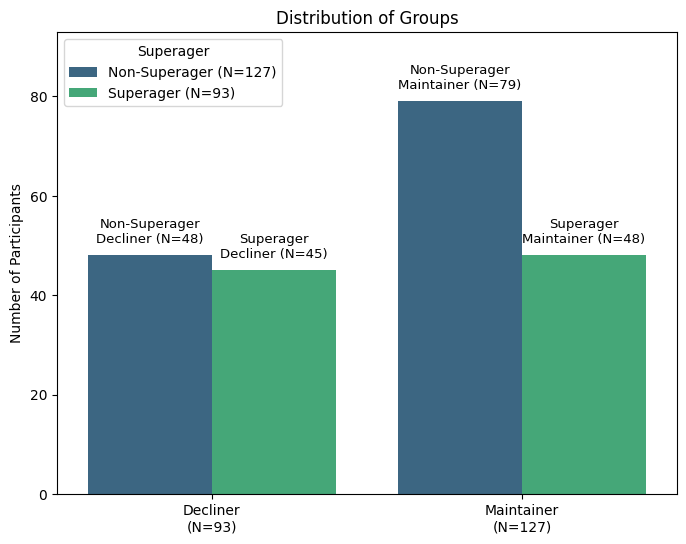

In [38]:
bbhi_senior_df = data[data["id"] < 10000]
bbhi_df = data[data["id"] > 10000]

# Calculate counts for each category in superager_maintainer
counts_superager_maintainer = data['superager_maintainer'].value_counts()

# Calculate counts for maintainer variable
counts_maintainer = data['maintainer'].value_counts()

# Calculate counts for superager variable
counts_superager = data['superager'].value_counts()

# Create custom labels for superager_maintainer combinations
custom_texts = [
    f"Non-Superager\nDecliner (N={counts_superager_maintainer.get('non-superager decliner', 0)})",
    f"Non-Superager\nMaintainer (N={counts_superager_maintainer.get('non-superager maintainer', 0)})",
    f"Superager\nDecliner (N={counts_superager_maintainer.get('superager decliner', 0)})",
    f"Superager\nMaintainer (N={counts_superager_maintainer.get('superager maintainer', 0)})"
]

# Plot grouped bar plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=data, x="maintainer", hue="superager", palette="viridis")

plt.title("Distribution of Groups")
plt.xlabel("")
plt.ylabel("Number of Participants")
plt.xticks(
    ticks=[0, 1],
    labels=[
        f"Decliner\n(N={counts_maintainer.get(0, 0)})",
        f"Maintainer\n(N={counts_maintainer.get(1, 0)})"
    ]
)

plt.legend(
    title="Superager",
    labels=[
        f"Non-Superager (N={counts_superager.get(0, 0)})",
        f"Superager (N={counts_superager.get(1, 0)})"
    ],
    loc='upper left'
)

# Add custom text above each bar
for i, p in enumerate(ax.patches):
    if i < len(custom_texts):
        custom_text = custom_texts[i]
        ax.annotate(
            custom_text,
            (p.get_x() + p.get_width() / 2.0, p.get_height() + 2),
            ha="center",
            va="bottom",
            fontsize=9.5,
            color="black"
        )

# Adjust y-axis limit to ensure text fits
ax.set_ylim(0, ax.get_ylim()[1] + 10)

plt.show()

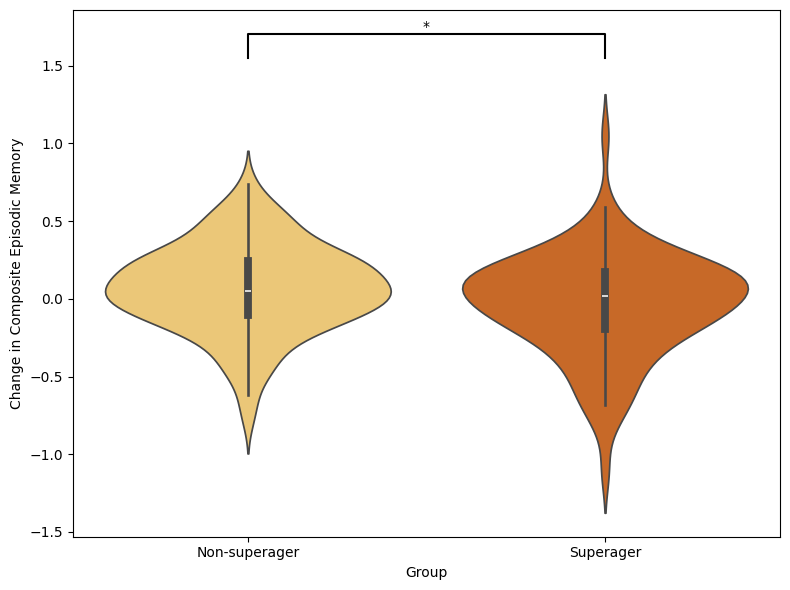

In [31]:
# Function to add significance lines
def add_sig_lines(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, color="black")
    ax.text((x1 + x2) * 0.5, y + h, text, ha="center", va="bottom")


# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Violin plot
sns.violinplot(ax=ax, data=data, x="superager", y="memory_slopes", palette="YlOrBr", hue="superager", legend=False)
ax.set_xlabel("Group")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-superager", "Superager"])
ax.set_ylabel("Change in Composite Episodic Memory")

# Conduct t-test for memory slopes and add significance label
y_max = data["memory_slopes"].max() + 0.5  # Start slightly above the max value
h = 0.1 * y_max
offset = 0.2 * y_max

group0 = data[data["superager"] == 0]["memory_slopes"]
group1 = data[data["superager"] == 1]["memory_slopes"]
t_stat, p_value = ttest_ind(group0.dropna(), group1.dropna())

if p_value < 0.001:
    add_sig_lines(ax, 0, 1, y_max, h, "***")
elif p_value < 0.01:
    add_sig_lines(ax, 0, 1, y_max, h, "**")
elif p_value < 0.05:
    add_sig_lines(ax, 0, 1, y_max, h, "*")

plt.tight_layout()
plt.show()

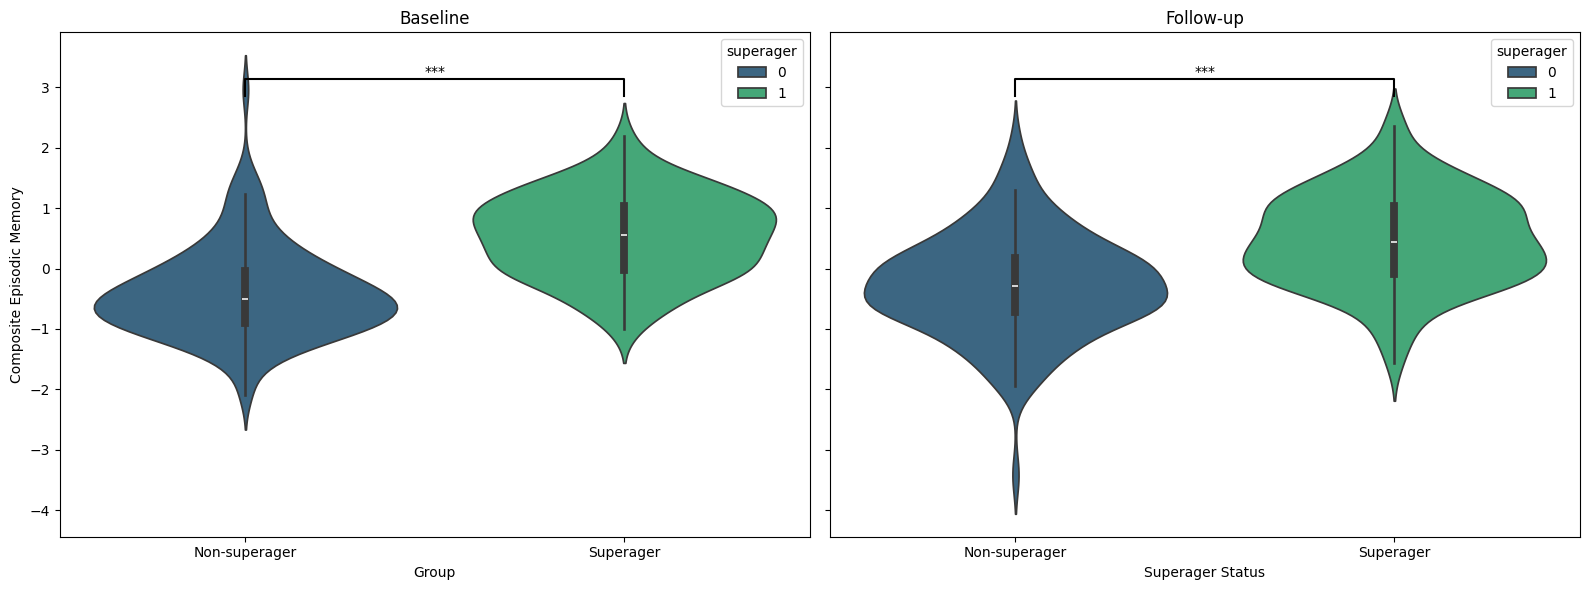

In [32]:
# Set up the subplot structure
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)


# Function to add significance lines
def add_sig_lines(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, color="black")
    ax.text((x1 + x2) * 0.5, y + h, text, ha="center", va="bottom")


# First violin plot
sns.violinplot(ax=axs[0], data=data, x="superager", y="w1_memory", palette="viridis", hue="superager")
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(["Non-superager", "Superager"])
axs[0].set_title("Baseline")
axs[0].set_xlabel("Group")
axs[0].set_ylabel("Composite Episodic Memory")

# Conduct t-test for tp1 memory and add significance label
y_max = data["w2_memory"].max() + 0.5  # Start slightly above the max value
h = 0.1 * y_max
offset = 0.2 * y_max

group0 = data[data["superager"] == 0]["w1_memory"]
group1 = data[data["superager"] == 1]["w1_memory"]
t_stat, p_value = ttest_ind(group0.dropna(), group1.dropna())

if p_value < 0.001:
    add_sig_lines(axs[0], 0, 1, y_max, h, "***")
elif p_value < 0.01:
    add_sig_lines(axs[0], 0, 1, y_max, h, "**")
elif p_value < 0.05:
    add_sig_lines(axs[0], 0, 1, y_max, h, "*")

# Second violin plot
sns.violinplot(ax=axs[1], data=data, x="superager", y="w2_memory", palette="viridis", hue="superager")
axs[1].set_xlabel("Superager Status")
axs[1].set_ylabel("")  # No need to repeat the ylabel
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(["Non-superager", "Superager"])
axs[1].set_title("Follow-up")

# Conduct t-test for tp2 memory and add significance label
y_max = data["w2_memory"].max() + 0.5  # Start slightly above the max value
h = 0.1 * y_max
offset = 0.2 * y_max

group0 = data[data["superager"] == 0]["w2_memory"]
group1 = data[data["superager"] == 1]["w2_memory"]
t_stat, p_value = ttest_ind(group0.dropna(), group1.dropna())

if p_value < 0.001:
    add_sig_lines(axs[1], 0, 1, y_max, h, "***")
elif p_value < 0.01:
    add_sig_lines(axs[1], 0, 1, y_max, h, "**")
elif p_value < 0.05:
    add_sig_lines(axs[1], 0, 1, y_max, h, "*")

# Adjust layout
plt.tight_layout()
plt.show()

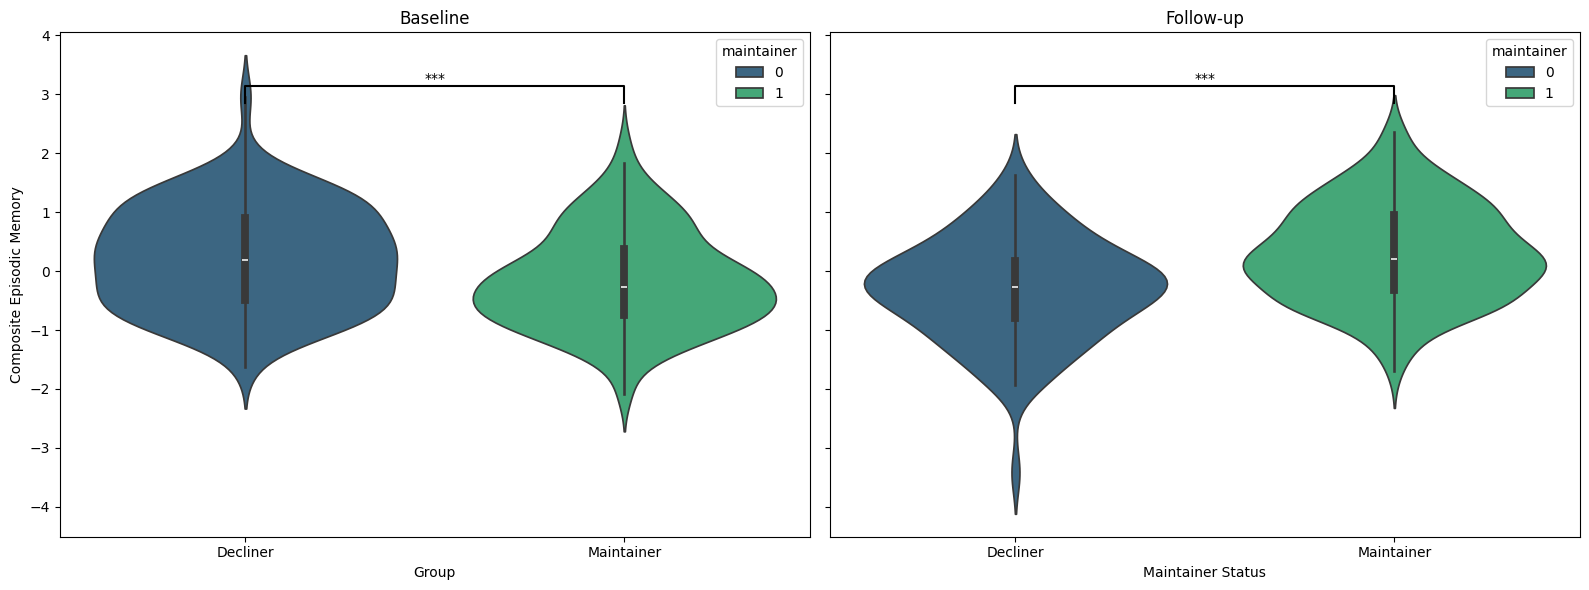

In [33]:
# Set up the subplot structure
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)


# Function to add significance lines
def add_sig_lines(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, color="black")
    ax.text((x1 + x2) * 0.5, y + h, text, ha="center", va="bottom")


# First violin plot
sns.violinplot(ax=axs[0], data=data, x="maintainer", y="w1_memory", palette="viridis", hue="maintainer")
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(["Decliner", "Maintainer"])
axs[0].set_title("Baseline")
axs[0].set_xlabel("Group")
axs[0].set_ylabel("Composite Episodic Memory")

# Conduct t-test for tp1 memory and add significance label
y_max = data["w2_memory"].max() + 0.5  # Start slightly above the max value
h = 0.1 * y_max
offset = 0.2 * y_max

group0 = data[data["maintainer"] == 0]["w1_memory"]
group1 = data[data["maintainer"] == 1]["w1_memory"]
t_stat, p_value = ttest_ind(group0.dropna(), group1.dropna())

if p_value < 0.001:
    add_sig_lines(axs[0], 0, 1, y_max, h, "***")
elif p_value < 0.01:
    add_sig_lines(axs[0], 0, 1, y_max, h, "**")
elif p_value < 0.05:
    add_sig_lines(axs[0], 0, 1, y_max, h, "*")

# Second violin plot
sns.violinplot(ax=axs[1], data=data, x="maintainer", y="w2_memory", palette="viridis", hue="maintainer")
axs[1].set_xlabel("Maintainer Status")
axs[1].set_ylabel("")  # No need to repeat the ylabel
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(["Decliner", "Maintainer"])
axs[1].set_title("Follow-up")

# Conduct t-test for tp2 memory and add significance label
y_max = data["w2_memory"].max() + 0.5  # Start slightly above the max value
h = 0.1 * y_max
offset = 0.2 * y_max

group0 = data[data["maintainer"] == 0]["w2_memory"]
group1 = data[data["maintainer"] == 1]["w2_memory"]
t_stat, p_value = ttest_ind(group0.dropna(), group1.dropna())

if p_value < 0.001:
    add_sig_lines(axs[1], 0, 1, y_max, h, "***")
elif p_value < 0.01:
    add_sig_lines(axs[1], 0, 1, y_max, h, "**")
elif p_value < 0.05:
    add_sig_lines(axs[1], 0, 1, y_max, h, "*")

# Adjust layout
plt.tight_layout()
plt.show()

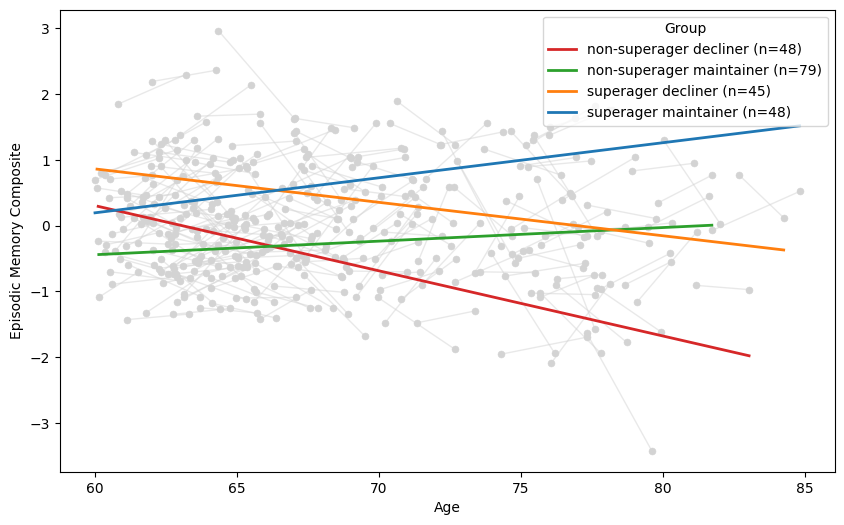

In [34]:
# Create a new DataFrame where each row corresponds to a unique id and timepoint
data_long = pd.DataFrame({
    "id": np.repeat(data["id"].values, 2),
    "age": data[["w1_age", "w2_age"]].values.flatten(),
    "memory": data[["w1_memory", "w2_memory"]].values.flatten(),
    "superager": np.repeat(data["superager"].values, 2),
    "maintainer": np.repeat(data["maintainer"].values, 2),
    "superager_maintainer": np.repeat(data["superager_maintainer"].values, 2),
})

# Fit the mixed-effects model
model = MixedLM.from_formula("memory ~ age * superager_maintainer", groups="id", data=data_long)
result = model.fit()

# Create the plot
plt.figure(figsize=(10, 6))

# Define colors for each superager_maintainer group
palette = {
    "superager maintainer": "#1f77b4",
    "superager decliner": "#ff7f0e",
    "non-superager maintainer": "#2ca02c",
    "non-superager decliner": "#d62728",
}

# Plot individual trajectories in light gray
for id in data_long["id"].unique():
    subset = data_long[data_long["id"] == id]
    sns.lineplot(data=subset, x="age", y="memory", color="lightgray", linewidth=1, alpha=0.5)

# Add scatter points for each participant without group-specific colors
sns.scatterplot(data=data_long, x="age", y="memory", color="lightgray", s=25, edgecolor="lightgray")

# Plot the fitted group line for each superager_maintainer group
for group in data_long["superager_maintainer"].unique():
    group_data = data_long[data_long["superager_maintainer"] == group]
    group_line = result.predict(group_data)
    sns.lineplot(x=group_data["age"], y=group_line, label=group, color=palette[group], linewidth=2)

# Customize the plot
plt.xlabel("Age")
plt.ylabel("Episodic Memory Composite")
plt.legend(title="Superager / Maintainer", loc="upper right")
handles, labels = plt.gca().get_legend_handles_labels()
counts = [
    f"{group} (n={data_long[data_long['superager_maintainer'] == group]['id'].nunique()})"
    for group in data_long["superager_maintainer"].unique()
]
plt.legend(handles=handles, labels=counts, title="Group", loc="upper right")
plt.show()

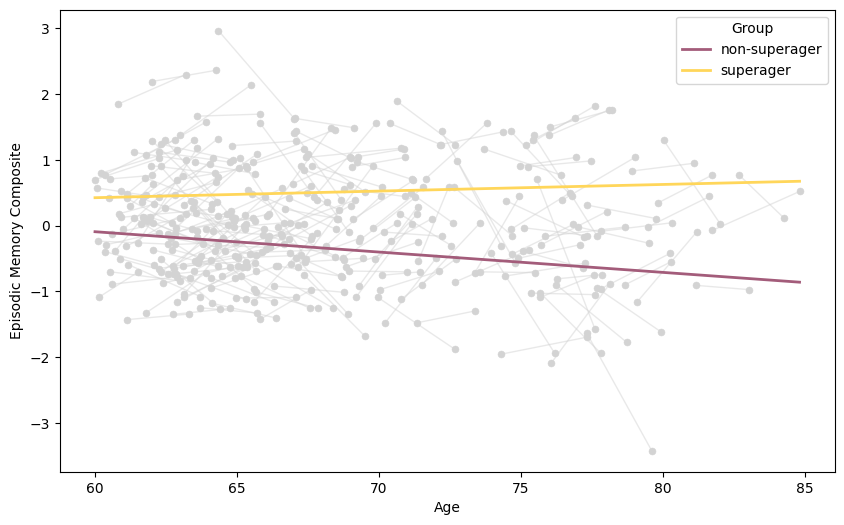

In [35]:
# Simulating the `data_long` DataFrame similarly to the working example
data_long = pd.DataFrame({
    "id": np.repeat(data["id"].values, 2),
    "age": data[["w1_age", "w2_age"]].values.flatten(),
    "memory": data[["w1_memory", "w2_memory"]].values.flatten(),
    "superager": np.repeat(data["superager"].values, 2),
    "superager_maintainer": np.repeat(data["superager_maintainer"].values, 2),
})

# Map superager values to strings
data_long['superager'] = data_long['superager'].astype(str).map({"0": "non-superager", "1": "superager"})

# Fit the mixed-effects model
model = MixedLM.from_formula("memory ~ age * superager", groups="id", data=data_long)
result = model.fit()

# Create the plot
plt.figure(figsize=(10, 6))

# Define colors for each superager group
palette = {
    "non-superager": "#A35C7A",
    "superager": "#FFD65A"
}

# Plot individual trajectories in light gray
for id in data_long["id"].unique():
    subset = data_long[data_long["id"] == id]
    sns.lineplot(data=subset, x="age", y="memory", color="lightgray", linewidth=1, alpha=0.5)

# Add scatter points for each participant
sns.scatterplot(data=data_long, x="age", y="memory", color="lightgray", s=25, edgecolor="lightgray")

# Generate smooth lines for each superager group
age_range = np.linspace(data_long["age"].min(), data_long["age"].max(), 100)

for group in data_long["superager"].unique():
    group_data = pd.DataFrame({
        "age": age_range,
        "superager": group
    })
    group_line = result.predict(group_data)
    sns.lineplot(x=age_range, y=group_line, label=group, color=palette[group], linewidth=2)

# Customize the plot
plt.xlabel("Age")
plt.ylabel("Episodic Memory Composite")
plt.legend(title="Group", loc="upper right")
plt.show()

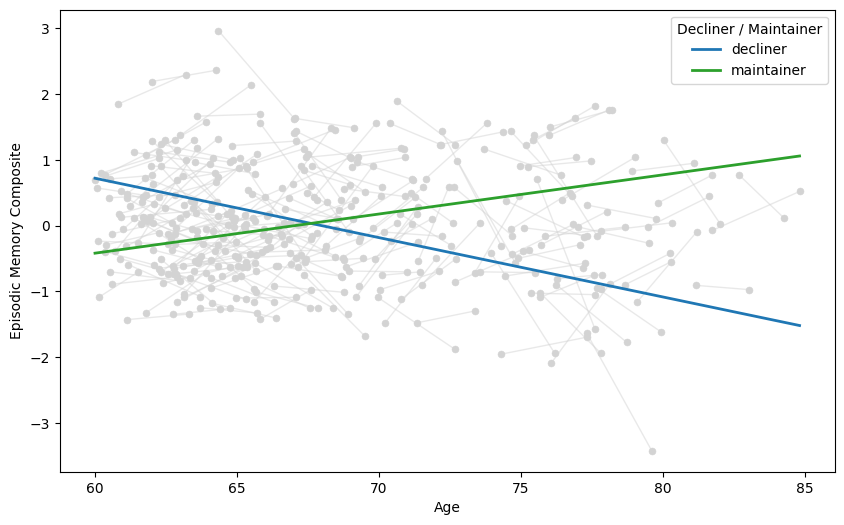

In [36]:
# Simulating the `data_long` DataFrame similarly to the working example
data_long = pd.DataFrame({
    "id": np.repeat(data["id"].values, 2),
    "age": data[["w1_age", "w2_age"]].values.flatten(),
    "memory": data[["w1_memory", "w2_memory"]].values.flatten(),
    "maintainer": np.repeat(data["maintainer"].values, 2),
})

data_long['maintainer'] = data_long['maintainer'].astype(str).map({"0": "decliner", "1": "maintainer"})

# Fit the mixed-effects model
model = MixedLM.from_formula("memory ~ age * maintainer", groups="id", data=data_long)
result = model.fit()

# Create the plot
plt.figure(figsize=(10, 6))

# Define colors for each superager group
palette = {
    "maintainer": "#2ca02c",
    "decliner": "#1f77b4"
}

# Plot individual trajectories in light gray
for id in data_long["id"].unique():
    subset = data_long[data_long["id"] == id]
    sns.lineplot(data=subset, x="age", y="memory", color="lightgray", linewidth=1, alpha=0.5)

# Add scatter points for each participant
sns.scatterplot(data=data_long, x="age", y="memory", color="lightgray", s=25, edgecolor="lightgray")

# Generate smooth lines for each maintainer group
age_range = np.linspace(data_long["age"].min(), data_long["age"].max(), 100)

for group in data_long["maintainer"].unique():
    group_data = pd.DataFrame({
        "age": age_range,
        "maintainer": group
    })
    group_line = result.predict(group_data)
    sns.lineplot(x=age_range, y=group_line, label=group, color=palette[group], linewidth=2)

# Customize the plot
plt.xlabel("Age")
plt.ylabel("Episodic Memory Composite")
plt.legend(title="Decliner / Maintainer", loc="upper right")
plt.show()

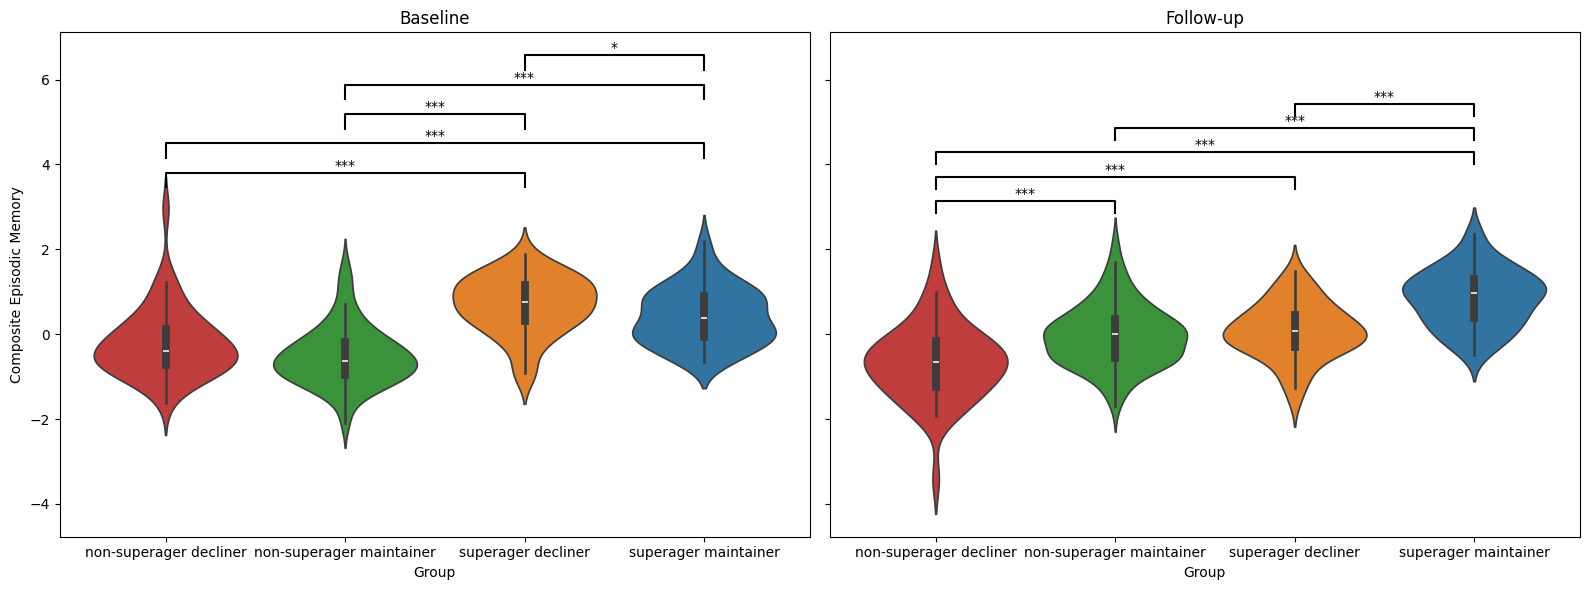

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Define colors for each superager_maintainer group
palette = {
    "superager maintainer": "#1f77b4",
    "superager decliner": "#ff7f0e",
    "non-superager maintainer": "#2ca02c",
    "non-superager decliner": "#d62728",
}

# Function to add significance lines
def add_sig_lines(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, color="black")
    ax.text((x1 + x2) * 0.5, y + h, text, ha="center", va="bottom")

# First violin plot
sns.violinplot(
    ax=axs[0],
    data=data,
    x="superager_maintainer",
    y="w1_memory",
    hue="superager_maintainer",
    palette=palette,
    legend=False,
)
axs[0].set_title("Baseline")
axs[0].set_xlabel("Group")
axs[0].set_ylabel("Composite Episodic Memory")
axs[0].set_xticks(range(len(palette)))

# Conduct significance testing for tp1 memory
y_max = data["w1_memory"].max() + 0.5
h = 0.1 * y_max
offset = 0.2 * y_max

for i, group1 in enumerate(palette.keys()):
    for j, group2 in enumerate(palette.keys()):
        if i < j:
            group1_data = data[data["superager_maintainer"] == group1]["w1_memory"]
            group2_data = data[data["superager_maintainer"] == group2]["w1_memory"]
            t_stat, p_value = ttest_ind(group1_data.dropna(), group2_data.dropna())
            if p_value < 0.001:
                add_sig_lines(axs[0], i, j, y_max, h, "***")
                y_max += offset
            elif p_value < 0.01:
                add_sig_lines(axs[0], i, j, y_max, h, "**")
                y_max += offset
            elif p_value < 0.05:
                add_sig_lines(axs[0], i, j, y_max, h, "*")
                y_max += offset

# Second violin plot
sns.violinplot(
    ax=axs[1],
    data=data,
    x="superager_maintainer",
    y="w2_memory",
    hue="superager_maintainer",
    palette=palette,
    legend=False,
)
axs[1].set_title("Follow-up")
axs[1].set_xlabel("Group")
axs[1].set_xticks(range(len(palette)))

# Conduct significance testing for tp2 memory
y_max = data["w2_memory"].max() + 0.5
h = 0.1 * y_max
offset = 0.2 * y_max

for i, group1 in enumerate(palette.keys()):
    for j, group2 in enumerate(palette.keys()):
        if i < j:
            group1_data = data[data["superager_maintainer"] == group1]["w2_memory"]
            group2_data = data[data["superager_maintainer"] == group2]["w2_memory"]
            t_stat, p_value = ttest_ind(group1_data.dropna(), group2_data.dropna())
            if p_value < 0.001:
                add_sig_lines(axs[1], i, j, y_max, h, "***")
                y_max += offset
            elif p_value < 0.01:
                add_sig_lines(axs[1], i, j, y_max, h, "**")
                y_max += offset
            elif p_value < 0.05:
                add_sig_lines(axs[1], i, j, y_max, h, "*")
                y_max += offset

# Adjust layout
plt.tight_layout()
plt.show()